In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import KMRF class
from kmrf import KMRF
from KMRF_training_config import *

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"  Pandas version: {pd.__version__}")
print(f"  NumPy version: {np.__version__}")

✓ Libraries imported successfully
  Pandas version: 2.3.3
  NumPy version: 2.3.4


## 1. Configure KMRF Model for Multi-Horizon Prediction

In [2]:
# Create DataFrame of asset names
asset_names_df = pd.DataFrame({
    'Investment Universe ETFs': get_assets_by_class('universe') + ['']*7,
    'US Equity ETFs': get_assets_by_class('us_equity'),
    'Commodities': get_assets_by_class('commodity') + ['']*5,
    'International Equity ETFs': get_assets_by_class('int_equity') + ['']*11,

})

# from pandas import option_context
# with option_context('display.max_colwidth', None):
#     display(asset_names_df)

In [3]:
# Configuration for multi-horizon prediction
TRAINING_CONFIG = KMRF_Training_Config(
    asset_name='SPDR S&P 500 ETF',
    classification_type='original',  # or 'adapted' for 3-class
    use_data_type='master',
    end_date='20251007',
    feature_window_size=1,
    feature_asset_classes=[],
    cross_asset_specific=[],
    use_boruta_selection=False,
    use_consensus_selection=False
)

# Multi-horizon specific settings
MAX_HORIZON = 21  # Predict up to 21 days forward
ASSET_NAME = 'SPDR S&P 500 ETF'
ASSET_CLASS = 'us_equity'
KAMAMSR_END_DATE = '20251007'


## 2. Initialize KMRF Model

In [4]:
# Initialize KMRF model
model = KMRF(
    asset_class=ASSET_CLASS,
    asset_name=ASSET_NAME,
    classification_type='original',
    end_date=KAMAMSR_END_DATE,
    use_data_type='master',
    feature_window_size=1,  
    feature_asset_classes=[],
    cross_asset_specific=[],
    xgb_params=TRAINING_CONFIG.get_xgb_params(),
    use_boruta_selection=False,
    use_consensus_selection=False,
)

print("\n" + "="*80)
print("KMRF MODEL INITIALIZED")
print("="*80)

KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: original
  Training end date: 20251007
  Test end date: All available data
  Data type: master
  Data path: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
  KAMA+MSR model directory: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/saved_models/KAMA_MSR/us_equity/20251007
  Validation/Test split: Will be calculated after loading data
  Random seed: 1010
  Feature window size: 1 days
  Feature asset classes: []
  Feature selection: Boruta=False, Consensus=False
  Custom XGB parameters: {'n_estimators': 220, 'max_depth': 13, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.25, 'min_child_weight': 95, 'gamma': 0.045, 'random_state': 1010, 'n_jobs': -1, 'tree_method': 'hist', 'enable_categorical': False}

KMRF MODEL INITIALIZED


## 3. Run Multi-Horizon Training Pipeline

This trains separate XGBoost models for each prediction horizon (1 to MAX_HORIZON days).

In [5]:
# Run the multi-horizon pipeline
model.pipeline_multi_horizon(max_horizon=MAX_HORIZON, verbose=False)


KMRF MULTI-HORIZON PIPELINE FOR SPDR S&P 500 ETF
Asset Class: us_equity
Classification Type: original
Data Type: master
Max Prediction Horizon: 21 days
Feature Asset Classes: []
Cross-Asset Specifics: []
Feature Window Size: 1
Use Boruta Selection: False
Use Consensus Selection: False

[Step 1/10] Loading Data...

Loading data from: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
Loaded data for: SPDR S&P 500 ETF
  Rows: 8246
  Columns: 94
  Date range: 1993-02-01 00:00:00 to 2025-10-31 00:00:00

[Step 2/10] Computing Features...

Extracting pre-computed features for SPDR S&P 500 ETF...
  Features shape: (8246, 94)

[Step 3/10] Loading KAMA+MSR Labels...

LOADING KAMA+MSR LABELS FOR SPDR S&P 500 ETF
Model directory: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/saved_models/KAMA_MSR/us_equity/20251007
Loading from: SPDR S&P 500 ETF_KAMA-MSR_4-regimes.pkl
Loaded data for: SPDR S&P 500 ETF
  Rows: 8246
  Columns: 94
  Date

KMRF('us_equity, SPDR S&P 500 ETF')
Raw OHLC Data (8247, 4): 1993-01-29 to 2025-10-31
Technical Features (8246, 94): 1993-02-01 to 2025-10-31
4-Regime Labels (7742): 1995-01-04 to 2025-10-07
Train (7490, 94): 1996-01-03 to 2025-10-07
Val (9, 94): 2025-10-08 to 2025-10-20
Test (9, 94): 2025-10-21 to 2025-10-31

## 4. Generate Multi-Horizon Predictions

In [6]:
# Generate multi-horizon predictions for all out-of-sample dates
all_oos_predictions = model.predict_multi_horizon_all_oos(horizon=MAX_HORIZON)

print(f"\nTotal prediction dates: {len(all_oos_predictions)}")
print(f"Date range: {min(all_oos_predictions.keys()).date()} to {max(all_oos_predictions.keys()).date()}")


Generating multi-horizon predictions for all OOS data...
  Horizon: 21 days
  Total dates: 18
  Date range: 2025-10-08 00:00:00 to 2025-10-31 00:00:00
  Processed 18/18 dates
✓ Generated multi-horizon predictions for 18 OOS dates

Total prediction dates: 18
Date range: 2025-10-08 to 2025-10-31


In [7]:
# Example: Access predictions for a specific date
example_date = list(all_oos_predictions.keys())[0]
print(f"\nPredictions starting from {example_date.date()}:")
display(all_oos_predictions[example_date])


Predictions starting from 2025-10-08:


,P(LV_Bull),P(LV_Bear),P(HV_Bull),P(HV_Bear)
horizon,,,,
1,0.998752,0.000360,0.000733,0.000156
2,0.998433,0.000431,0.000964,0.000173
3,0.997500,0.000606,0.001610,0.000283
4,0.996220,0.000666,0.002557,0.000557
5,0.995366,0.000842,0.002936,0.000857
6,0.994191,0.001091,0.003570,0.001148
7,0.994308,0.000885,0.003664,0.001142
8,0.995122,0.000799,0.003017,0.001062
9,0.994974,0.000709,0.003283,0.001035


## 5. Analyze Multi-Horizon Predictions

In [8]:
# Convert predictions to a more analyzable format
# Create a DataFrame with (date, horizon) as multi-index

records = []
for date, pred_df in all_oos_predictions.items():
    for horizon in pred_df.index:
        row = {'date': date, 'horizon': horizon}
        row.update(pred_df.loc[horizon].to_dict())
        records.append(row)

predictions_flat = pd.DataFrame(records)
predictions_flat = predictions_flat.set_index(['date', 'horizon'])

print(f"Flattened predictions shape: {predictions_flat.shape}")
display(predictions_flat.head(25))

Flattened predictions shape: (378, 4)


P(LV_Bull)  P(LV_Bear)  P(HV_Bull)  P(HV_Bear)
date       horizon                                                
2025-10-08 1          0.998752    0.000360    0.000733    0.000156
           2          0.998433    0.000431    0.000964    0.000173
           3          0.997500    0.000606    0.001610    0.000283
           4          0.996220    0.000666    0.002557    0.000557
           5          0.995366    0.000842    0.002936    0.000857
           6          0.994191    0.001091    0.003570    0.001148
           7          0.994308    0.000885    0.003664    0.001142
           8          0.995122    0.000799    0.003017    0.001062
           9          0.994974    0.000709    0.003283    0.001035
           10         0.994599    0.000646    0.003613    0.001142
           11         0.994491    0.000560    0.003658    0.001291
           12         0.994220    0.000589    0.003576    0.001616
           13         0.993499    0.000676    0.003795    0.002030
           14         0.993538    0.000755    0.003670    0.002037
           15         0.993572    0.000824    0.003493    0.002111
           16         0.993867    0.000975    0.003072    0.002086
           17         0.994917    0.000853    0.002657    0.001573
           18         0.995310    0.000734    0.002592    0.001364
           19         0.993955    0.001233    0.003162    0.001651
           20         0.995174    0.000881    0.002465    0.001481
           21         0.996712    0.000765    0.001556    0.000967
2025-10-09 1          0.998318    0.000615    0.000861    0.000206
           2          0.998253    0.000525    0.001008    0.000215
           3          0.997078    0.000806    0.001749    0.000367
           4          0.995810    0.000777    0.002785    0.000628

In [9]:
# Analyze how predictions change across horizons
# Average probability by horizon
avg_by_horizon = predictions_flat.groupby('horizon').mean()

print("Average regime probabilities by horizon:")
display(avg_by_horizon)

Average regime probabilities by horizon:


,P(LV_Bull),P(LV_Bear),P(HV_Bull),P(HV_Bear)
horizon,,,,
1,0.996828,0.000777,0.002024,0.000371
2,0.995873,0.000808,0.002872,0.000448
3,0.993499,0.001018,0.004591,0.000891
4,0.992005,0.001219,0.005441,0.001335
5,0.992658,0.000948,0.004842,0.001552
6,0.992499,0.001061,0.004752,0.001688
7,0.992261,0.001426,0.004622,0.001691
8,0.990074,0.002175,0.005561,0.002191
9,0.991065,0.002269,0.004861,0.001804


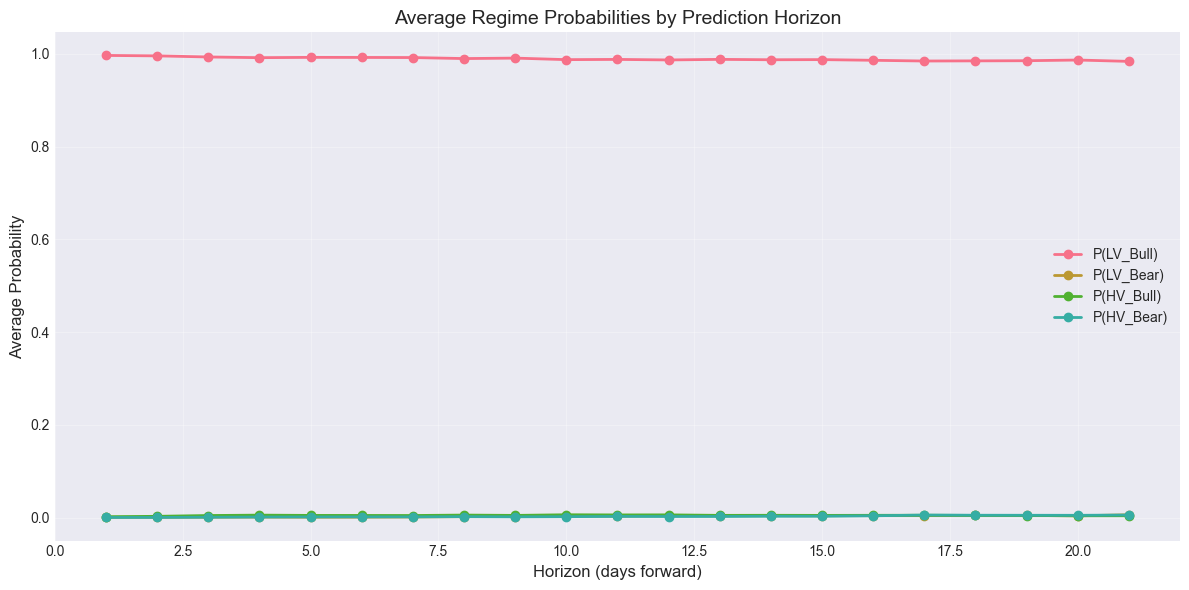

In [10]:
# Visualize average probabilities across horizons
fig, ax = plt.subplots(figsize=(12, 6))

avg_by_horizon.plot(kind='line', marker='o', ax=ax, linewidth=2, markersize=6)

ax.set_xlabel('Horizon (days forward)', fontsize=12)
ax.set_ylabel('Average Probability', fontsize=12)
ax.set_title('Average Regime Probabilities by Prediction Horizon', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Compare horizon=1 vs horizon=21 predictions
h1_preds = predictions_flat.xs(1, level='horizon')
h21_preds = predictions_flat.xs(MAX_HORIZON, level='horizon')

print(f"Correlation between h=1 and h={MAX_HORIZON} predictions:")
for col in h1_preds.columns:
    corr = h1_preds[col].corr(h21_preds[col])
    print(f"  {col}: {corr:.4f}")

Correlation between h=1 and h=21 predictions:
  P(LV_Bull): 0.7875
  P(LV_Bear): -0.1664
  P(HV_Bull): 0.3114
  P(HV_Bear): 0.7432


## 6. Compare with Standard (Single-Horizon) Predictions

In [12]:
# Standard predict() uses horizon=1 model (backward compatible)
standard_predictions = model.predict_all_oos()

print(f"Standard predictions shape: {standard_predictions.shape}")
display(standard_predictions.head())


Generating predictions for all out-of-sample data...
  Input shape: (19, 122)
  Date range: 2025-10-07 00:00:00 to 2025-10-31 00:00:00
✓ Generated predictions for all OOS data: (19, 4)
  Date range: 2025-10-07 00:00:00 to 2025-10-31 00:00:00
Standard predictions shape: (19, 4)


,P(LV_Bull),P(LV_Bear),P(HV_Bull),P(HV_Bear)
date,,,,
2025-10-07,0.998510,0.000387,0.000893,0.000210
2025-10-08,0.998431,0.000380,0.001005,0.000183
2025-10-09,0.998456,0.000408,0.000908,0.000229
2025-10-10,0.998681,0.000343,0.000811,0.000166
2025-10-13,0.995581,0.000408,0.003550,0.000462


In [13]:
# Verify horizon=1 multi-horizon predictions match standard predictions
h1_from_multi = predictions_flat.xs(1, level='horizon')

# Align indices
common_dates = h1_from_multi.index.intersection(standard_predictions.index)
h1_aligned = h1_from_multi.loc[common_dates]
std_aligned = standard_predictions.loc[common_dates]

print("Verification: Multi-horizon h=1 vs Standard predictions")
print(f"Common dates: {len(common_dates)}")
for col in h1_aligned.columns:
    if col in std_aligned.columns:
        diff = (h1_aligned[col] - std_aligned[col]).abs().mean()
        print(f"  {col} mean absolute difference: {diff:.6f}")

Verification: Multi-horizon h=1 vs Standard predictions
Common dates: 19
  P(LV_Bull) mean absolute difference: 0.000000
  P(LV_Bear) mean absolute difference: 0.000000
  P(HV_Bull) mean absolute difference: 0.000000
  P(HV_Bear) mean absolute difference: 0.000000


## 7. Save Model

In [14]:
# Save the multi-horizon trained model
path = f'saved_models/KMRF_new/{model.classification_type}/{model.asset_class}/'
path += f'{model.asset_name.replace(" ", "_")}_KMRF_multi_horizon_model.pkl'
model.save_model(path)
print(f"\n✓ Model saved to: {path}")


Saving model to: saved_models/KMRF_new/original/us_equity/SPDR_S&P_500_ETF_KMRF_multi_horizon_model.pkl
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: original
  Features: all
  Training samples: 7489
✓ Model saved successfully

✓ Model saved to: saved_models/KMRF_new/original/us_equity/SPDR_S&P_500_ETF_KMRF_multi_horizon_model.pkl
✓ Model saved successfully

✓ Model saved to: saved_models/KMRF_new/original/us_equity/SPDR_S&P_500_ETF_KMRF_multi_horizon_model.pkl


## 8. Load and Test Saved Model

In [15]:
# Load the saved model
loaded_model = KMRF.load_model(path, verbose=True)

# Verify multi-horizon predictions work after loading
loaded_predictions = loaded_model.predict_multi_horizon(horizon=MAX_HORIZON, test_or_val='val')
print(f"\n✓ Loaded model predictions shape: {loaded_predictions.shape}")
display(loaded_predictions.head())


LOADING SAVED KMRF MODEL
Model path: saved_models/KMRF_new/original/us_equity/SPDR_S&P_500_ETF_KMRF_multi_horizon_model.pkl
KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: original
  Training end date: 20251007
  Test end date: All available data
  Data type: master
  Data path: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
  KAMA+MSR model directory: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/saved_models/KAMA_MSR/us_equity/20251007
  Validation/Test split: Will be calculated after loading data
  Random seed: 1010
  Feature window size: 1 days
  Feature asset classes: []
  Feature selection: Boruta=False, Consensus=False
  Custom XGB parameters: {'n_estimators': 220, 'max_depth': 13, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.25, 'min_child_weight': 95, 'gamma': 0.045, 'random_state': 1010, 'n_jobs': -1, 'tree_method': 'hist', 'enable_categorical':

ValueError: Multi-horizon models not trained. Call fit_multi_horizon() first.